# **0. Описание ноутбука**

**Целью ноутбука** является выбрать среди базовых моделей наилучшую модель для дальнейшего его развития и использования

**Содержание:**
1. Подготовка датасета, библиотек, функций и переменных;
2. Обучение моделей;
3. Общей итог работы.

**Обучение и сравнение моделей:**
В ноутбуке присуствуют такие модели как:
```
Логистическая регрессия, SVM, Дерево значений, Случайный лес, Стекинг, CatBoost
```
Для каждой модели будут представлены 3 варианта данных для сравнения и подтверждения какая лучше на практике:

1.   Без BMI, но с Ростом и Весом
2.   С BMI, но без Роста и Веса
3.   Без BMI и без Роста и Веса

Для сравнение обратим внимание на такие метрики:
- F1-Score
- Log Loss
- Roc-auc
- Время обучения
- Precision
- Recall
- Accuracy


Важными метриками для нас являются:
- **F1-Score** из-за средних показателей Precision и Recall, а также из-за в отличие от Accuracy более надежен при дисбалансе классов;
- **Время обучения**, т.к. показывает скорость обучения;
- **Log Loss** для показа насколько можно довериться вроятностям модели;
- **ROC-AUC** для показа способности модели разделять классы.


# **1.1. Подготовка данных и инструментов**

*Описание импортов библиотек и готовых данных и инструментов*

## Загрузка и обработка данных

In [1]:
from pathlib import Path
import sys, os

REPO_DIR = 'Multiclass_prediction_of_obesity_risk'
REPO_URL = 'https://github.com/AlexTilta/Multiclass_prediction_of_obesity_risk.git'

if not os.path.isdir(REPO_DIR):
    print("Репозиторий не найден. Клонирование и установка зависимостей...")
    !git clone {REPO_URL}

    !pip -q install -r {REPO_DIR}/requirements.txt
else:
    print(f"Репозиторий '{REPO_DIR}' уже склонирован.")

%cd {REPO_DIR}

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))


from src.utils import load_csv

df_original = load_csv('prepared_data.csv', 'data')
df_original.head()

Репозиторий 'Multiclass_prediction_of_obesity_risk' уже склонирован.
c:\Users\Пользователь\OneDrive\Desktop\sasha_folder\Multiclass_prediction_of_obesity_risk\Multiclass_prediction_of_obesity_risk


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0,1.62,64.0,yes,no,Sometimes,3,Sometimes,no,1-2,no,0,3-5,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,Always,3,Sometimes,yes,>2,yes,4-5,0-2,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,Sometimes,3,Sometimes,no,1-2,no,2-4,3-5,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,Always,3,Sometimes,no,1-2,no,2-4,0-2,Frequently,Walking,Overweight,26.851852
4,Male,22.0,1.78,89.8,no,no,Sometimes,1-2,Sometimes,no,1-2,no,0,0-2,Sometimes,Public_Transportation,Overweight,28.342381


 ## Установка библиотек

In [2]:
!pip show catboost || pip install catboost
!pip show phik || pip install phik

Name: catboost
Version: 1.2.8
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: C:\Users\Пользователь\AppData\Roaming\Python\Python313\site-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 
Name: phik
Version: 0.12.5
Summary: Phi_K correlation analyzer library
Home-page: 
Author: 
Author-email: "KPMG N.V. The Netherlands" <kave@kpmg.com>
License: 
Location: C:\Users\Пользователь\AppData\Roaming\Python\Python313\site-packages
Requires: joblib, matplotlib, numpy, pandas, scipy
Required-by: ydata-profiling


## Библиотеки

In [3]:
# Общие библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import optuna

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, PolynomialFeatures
)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, log_loss, roc_auc_score
)
# Библиотеки для отчетов
import json
import time
from IPython.display import display

# Утилиты
import joblib
import warnings
warnings.filterwarnings('ignore')
from phik import phik_matrix


# Библиотеки моделей или для конкретных моделей
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, StackingClassifier
)
from catboost import CatBoostClassifier, Pool, cv


C:\Users\Пользователь\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **1.2. Настройка датасета**

*Описание констант для датасета(для быстрой настройки) и преобразования категориальных данных в числовые*

## Константы (для отчетов и редактирования наименований признаков)

In [4]:
# Целева переменная
TARGET_COLUMN = 'NObeyesdad'

# Константы для разных видов данных
ANTHROPOMETRICS = ['Height', 'Weight', 'BMI']

COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY = [TARGET_COLUMN, 'BMI']
COLUMNS_TO_DROP_BMI_ONLY = [TARGET_COLUMN, 'Height', 'Weight']
COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED = [TARGET_COLUMN] + ANTHROPOMETRICS

## Преобразование данных для большинство моделей

In [5]:
# Копирование данных (оригинал пригодится для CatBoost)
df_transformed = df_original.copy()

# Подготовка для преобразования строковых признаков
caec_calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_transformed['CAEC'] = df_transformed['CAEC'].replace(caec_calc_map)
df_transformed['CALC'] = df_transformed['CALC'].replace(caec_calc_map)

fcvc_map = {'no': 0, 'Sometimes': 1, 'Always': 2}
df_transformed['FCVC'] = df_transformed['FCVC'].replace(fcvc_map)

ncp_map = {'1-2': 1.5, '3': 3.0, '>3': 3.5}
df_transformed['NCP'] = df_transformed['NCP'].replace(ncp_map)

ch2o_map = {'<1': 0.5, 'Sometimes': 1.0, '1-2': 1.5, '>2': 3.0}
df_transformed['CH2O'] = df_transformed['CH2O'].replace(ch2o_map)

faf_tue_map = {'0': 0, 'no': 0, '0-2': 1, '1-2': 1, '2-4': 3,
               '3-5': 4, '4-5': 4, '>5': 5}
df_transformed['FAF'] = df_transformed['FAF'].replace(faf_tue_map)
df_transformed['TUE'] = df_transformed['TUE'].replace(faf_tue_map)

yes_no_map = {'yes': 1.0, 'no': 0.0}
df_transformed['family_history_with_overweight'] = df_transformed['family_history_with_overweight'].replace(yes_no_map)
df_transformed['FAVC'] = df_transformed['FAVC'].replace(yes_no_map)
df_transformed['SMOKE'] = df_transformed['SMOKE'].replace(yes_no_map)
df_transformed['SCC'] = df_transformed['SCC'].replace(yes_no_map)

gender_map = {'Male': 1.0, 'Female': 0.0}
df_transformed['Gender'] = df_transformed['Gender'].replace(gender_map)

# Преобразование
mtrans_le = LabelEncoder()
df_transformed['MTRANS'] = mtrans_le.fit_transform(df_transformed['MTRANS']).astype(float)

df = df_transformed

INT_COLUMNS = ['FCVC', 'CAEC', 'FAF', 'TUE', 'CALC']
INT_COLUMNS_ADJUSTED = [col for col in INT_COLUMNS if col in df.columns]

for col in INT_COLUMNS_ADJUSTED:
    df[col] = df[col].astype('Int64')

EXCLUDE_COLUMNS = [TARGET_COLUMN] + INT_COLUMNS_ADJUSTED

COLUMNS_TO_FLOAT = [col for col in df.columns if col not in EXCLUDE_COLUMNS]

for col in COLUMNS_TO_FLOAT:
    try:
        df[col] = df[col].astype(float)
    except Exception as e:
        pass

# Вывод
print(df.dtypes)
df

Gender                            float64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight    float64
FAVC                              float64
FCVC                                Int64
NCP                               float64
CAEC                                Int64
SMOKE                             float64
CH2O                              float64
SCC                               float64
FAF                                 Int64
TUE                                 Int64
CALC                                Int64
MTRANS                            float64
NObeyesdad                         object
BMI                               float64
dtype: object


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0.0,21.000000,1.620000,64.000000,1.0,0.0,1,3.0,1,0.0,1.5,0.0,0,4,0,3.0,Normal_Weight,24.386526
1,0.0,21.000000,1.520000,56.000000,1.0,0.0,2,3.0,1,1.0,3.0,1.0,4,1,1,3.0,Normal_Weight,24.238227
2,1.0,23.000000,1.800000,77.000000,1.0,0.0,1,3.0,1,0.0,1.5,0.0,3,4,2,3.0,Normal_Weight,23.765432
3,1.0,27.000000,1.800000,87.000000,0.0,0.0,2,3.0,1,0.0,1.5,0.0,3,1,2,4.0,Overweight,26.851852
4,1.0,22.000000,1.780000,89.800000,0.0,0.0,1,1.5,1,0.0,1.5,0.0,0,1,1,3.0,Overweight,28.342381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0.0,20.976842,1.710730,131.408528,1.0,1.0,2,3.0,1,0.0,1.5,0.0,3,4,1,3.0,Obesity,44.901475
2083,0.0,21.982942,1.748584,133.742943,1.0,1.0,2,3.0,1,0.0,1.5,0.0,1,4,1,3.0,Obesity,43.741923
2084,0.0,22.524036,1.752206,133.689352,1.0,1.0,2,3.0,1,0.0,1.5,0.0,1,4,1,3.0,Obesity,43.543817
2085,0.0,24.361936,1.739450,133.346641,1.0,1.0,2,3.0,1,0.0,3.0,0.0,1,4,1,3.0,Obesity,44.071535


# **1.3. Переменные и функции для отчетности**

## Переменные для отчета

In [6]:
# Константы для названий моделей
MODEL_NAMES = {
    "log_reg": "Логистическая регрессия",
    "svm": "Модель SVM",
    "tree": "Деревья",
    "rf": "Случайный лес",
    "stacking": "Стекинг",
    "cat_boost": "CatBoost"
}

# Константы для названий метрик
METRIC_COLUMNS = {
    "F1": "F1-Score",
    "ACCURACY": "Accuracy",
    "PRECISION" : "Precision",
    "RECALL": "Recall)",
    "ROC_AUC": "ROC_AUC",
    "LogLoss": "LogLoss",
    "TIME": "Время CV (сек)"
}

# Сохранение результатов
result_hw = {}
result_bmi = {}
result_no_anthro = {}

## Функции для отчета

In [7]:
# Вывод таблицы
def display_formatted_table(comparison_results: dict):
    if not comparison_results:
        print("Словарь результатов пуст.")
        return

    df_results = pd.DataFrame.from_dict(comparison_results, orient='index')

    try:
        df_sorted = df_results.sort_values(
            by=METRIC_COLUMNS["F1"],
            ascending=False
        )
    except KeyError:
        print(f"Ошибка: В результатах отсутствует колонка для сортировки по F1-метрике ('{METRIC_COLUMNS['F1']}'). Сортировка пропущена.")
        df_sorted = df_results

    pd.options.display.float_format = '{:.4f}'.format

    try:
        if METRIC_COLUMNS["TIME"] in df_sorted.columns:
            df_sorted[METRIC_COLUMNS["TIME"]] = pd.to_numeric(df_sorted[METRIC_COLUMNS["TIME"]], errors='coerce')
            df_sorted[METRIC_COLUMNS["TIME"]] = df_sorted[METRIC_COLUMNS["TIME"]].apply(lambda x: f'{x:.2f}')
    except Exception as e:
        print(f"Ошибка при форматировании колонки времени '{METRIC_COLUMNS['TIME']}': {e}")

    display(df_sorted)

# **1.4. Общие объявления и функции для моделей**

*Общие переменные и функции для дальнейшего обучения*

## Объявления x, y, а также тренировочных и тестовых переменных

Для дальнейших возможностей запускать по отдельности каждый блок были объявлены три вариации значений.

### - Без BMI

In [8]:
# Для большинства моделей (df)
X_HW = df.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y = df[TARGET_COLUMN]
X_HW_train, X_HW_test, Y_HW_train, Y_HW_test = train_test_split(X_HW, Y, random_state=42, stratify=Y)

# Для CatBoost (df_original)
X_HW_cat = df_original.drop(columns=COLUMNS_TO_DROP_HEIGHT_WEIGHT_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_HW_cat_train, X_HW_cat_test, Y_HW_cat_train, Y_HW_cat_test = train_test_split(X_HW_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### - C BMI

In [9]:

# Для большинства моделей (df)
X_BMI = df.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y = df[TARGET_COLUMN]
X_BMI_train, X_BMI_test, Y_BMI_train, Y_BMI_test = train_test_split(X_BMI, Y, random_state=42, stratify=Y)


# Для CatBoost (df_original)
X_BMI_cat = df_original.drop(columns=COLUMNS_TO_DROP_BMI_ONLY)
Y_cat = df_original[TARGET_COLUMN]
X_BMI_cat_train, X_BMI_cat_test, Y_BMI_cat_train, Y_BMI_cat_test = train_test_split(X_BMI_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

### - Без BMI, без Роста и вес

In [10]:
# Для большинства моделей (df)
X_NO_ANTHRO = df.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y = df[TARGET_COLUMN]
X_NO_ANTHRO_train, X_NO_ANTHRO_test, Y_NO_ANTHRO_train, Y_NO_ANTHRO_test = train_test_split(X_NO_ANTHRO, Y, random_state=42, stratify=Y)

# Для CatBoost (df_original)
X_NO_ANTHRO_cat = df_original.drop(columns=COLUMNS_TO_DROP_ANTHROPOMETRICS_EXCLUDED)
Y_cat = df_original[TARGET_COLUMN]
X_NO_ANTHRO_cat_train, X_NO_ANTHRO_cat_test, Y_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_test = train_test_split(X_NO_ANTHRO_cat, Y_cat, random_state=42)

cat_features = ['Gender', 'family_history_with_overweight', 'FCVC', 'FAVC', 'CAEC', 'CH2O', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NCP', 'FAF', 'TUE']

## Функции для запуска моделей и вывода их результата

Также в этих функциях происходит получение отчетности данных точности и времени

**make_model** - для большинства моделей

In [11]:
def make_model(pipeline, x, y, model_name, results_dict):
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    class_names = [str(c) for c in sorted(y.unique())]

# Предсказание классов
    start_time = time.time()

    y_pred_cv_full = cross_val_predict(estimator=pipeline,
                                       X=x,
                                       y=y,
                                       cv=stratified_kfold,
                                       n_jobs=-1)

# Предсказание вероятностей (нужно для LogLoss и ROC_AUC)
    y_proba_cv_full = cross_val_predict(estimator=pipeline,
                                        X=x,
                                        y=y,
                                        cv=stratified_kfold,
                                        n_jobs=-1,
                                        method='predict_proba')

    end_time = time.time()
    cv_time_seconds = end_time - start_time

    # Метрики
    report = classification_report(y, y_pred_cv_full, target_names=class_names, output_dict=True)

    weighted_f1_score = report['weighted avg']['f1-score']
    weighted_recall = report['weighted avg']['recall']
    weighted_precision = report['weighted avg']['precision']
    overall_accuracy = report['accuracy']

    logloss_score = log_loss(y, y_proba_cv_full)

    roc_auc_score_multiclass = roc_auc_score(
        y,
        y_proba_cv_full,
        multi_class='ovr',
        average='weighted'
    )

# Сохранение результатов
    results_dict[model_name] = {
          METRIC_COLUMNS["F1"]: weighted_f1_score,
          METRIC_COLUMNS["ACCURACY"]: overall_accuracy,
          METRIC_COLUMNS["LogLoss"]: logloss_score,
          METRIC_COLUMNS["RECALL"]: weighted_recall,
          METRIC_COLUMNS["PRECISION"]: weighted_precision,
          METRIC_COLUMNS["ROC_AUC"]: roc_auc_score_multiclass,
          METRIC_COLUMNS["TIME"]: cv_time_seconds
      }

# Выводы
    print(f"\nОбучение модели {model_name} заняло: {cv_time_seconds:.4f} секунд.")
    print("Classification Report - Full Model CV:")
    print(classification_report(y, y_pred_cv_full, target_names=class_names))
    print(f"\nLogLoss (Multiclass): {logloss_score:.4f}")
    print(f"ROC_AUC (Weighted OVR): {roc_auc_score_multiclass:.4f}")
    cm = confusion_matrix(y, y_pred_cv_full)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

**make_catboost_model** - только для catboost

**Заметка**:

Можно заметить, что в cv не будет строиться ни матрица ошибки и не будут находиться некоторые метрики. Причиной этому является либо невозможность получить эти значения с функции, либо незнание как можно получить эти метрики.

Для нас одни из главных метрик больше являются F1 и LogLoss, поэтому их значения получить удалось.

К тому же в дальнейшем CatBoost покажет хорошие результаты, но все же другим моделя он будет уступать, поэтому попытки как-то получить данные метрики с CatBoost было решено оставить как есть.

In [12]:
def make_catboost_model(model, x, y, cat_features, model_name, results_dict):
    start_time = time.time()

    params = model.get_params()

    params['custom_metric'] = ['TotalF1', 'Accuracy']

    # Обучение модели
    cv_data = cv(
        Pool(x, y, cat_features=cat_features),
        params,
        fold_count=5,
        seed=42,
        logging_level='Silent'
    )

    end_time = time.time()
    cv_time_seconds = end_time - start_time

    # Метрики
    accuracy = cv_data['test-Accuracy-mean'].max()
    best_f1 = cv_data['test-TotalF1-mean'].max()

    logloss = cv_data['test-MultiClass-mean'].min()

    #  NaN для всех недоступных метрик
    precision = np.nan
    recall = np.nan
    roc_auc = np.nan

    results_dict[model_name] = {
        METRIC_COLUMNS["F1"]: best_f1,
        METRIC_COLUMNS["ACCURACY"]: accuracy,
        METRIC_COLUMNS["LogLoss"]: logloss,
        METRIC_COLUMNS["RECALL"]: recall,
        METRIC_COLUMNS["PRECISION"]: precision,
        METRIC_COLUMNS["ROC_AUC"]: roc_auc,
        METRIC_COLUMNS["TIME"]: cv_time_seconds
    }

    print(f"CatBoost CV завершен.")
    print(f"- F1: {best_f1:.4f}")
    print(f"- MultiClassLoss: {logloss:.4f}")
    print(f"- Accuracy: {accuracy:.4f}")
    print(f"- Время: {cv_time_seconds:.2f} секунд")

**display_final_model_evaluation** нужен для обучения на тестовых значениях

In [13]:
def display_final_model_evaluation(model, X_train, Y_train, X_test, Y_test, model_name):
    print(f"Запуск финального обучения модели {model_name}...")
    start_time = time.time()
    model.fit(X_train, Y_train)
    fit_time = time.time() - start_time
    print(f"\nОбучение модели {model_name} заняло: {fit_time:.4f} секунд.")

    y_pred_test = model.predict(X_test)

    logloss_score = np.nan
    roc_auc_score_multiclass = np.nan

    try:
        y_proba_test = model.predict_proba(X_test)

        logloss_score = log_loss(Y_test, y_proba_test)

        roc_auc_score_multiclass = roc_auc_score(
            Y_test,
            y_proba_test,
            multi_class='ovr',
            average='weighted'
        )

    except AttributeError:
        print("\nВНИМАНИЕ: Модель не поддерживает predict_proba. LogLoss и ROC_AUC пропущены.")

    class_names = [str(c) for c in sorted(Y_test.unique())]

    print(f"\n--- Classification Report для {model_name} на Тесте ---")
    print(classification_report(Y_test, y_pred_test, target_names=class_names))

    if not np.isnan(logloss_score):
        print(f"LogLoss (Multiclass): {logloss_score:.4f}")
        print(f"ROC_AUC (Weighted OVR): {roc_auc_score_multiclass:.4f}")

    cm_test = confusion_matrix(Y_test, y_pred_test)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_test,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# **2.1. Общее описание  моделей**

В дальнейших пунктах 2.* будут продемонстрированы базовые модели с тремя вариациями данных. Итогами их будут выводы доступных значение, матриц и графиков.

В пункте 3 на таблицах сравнения будет сделан общий вывод для всех моделей

# **2.2. Логистическая регрессия**

### Вынесем отдельно функцию для подбора гиперпараметров логистической ресрессии с помощью Optuna

In [ ]:
def log_reg_study(X_train, Y_train):
    def objective(trial):
        
        params = {
            'logisticregression__C': trial.suggest_float('C', 0.001, 1000, log=True),
            'logisticregression__penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
            'logisticregression__solver': trial.suggest_categorical('solver', ['lbfgs', 'newton-cg', 'sag', 'saga', 'liblinear']),
            'logisticregression__max_iter': trial.suggest_int('max_iter', 100, 2000),
            'logisticregression__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
            'logisticregression__multi_class': trial.suggest_categorical('multi_class', ['ovr', 'multinomial', 'auto'])
        }
        
        if params['logisticregression__penalty'] == 'elasticnet':
            params['logisticregression__l1_ratio'] = trial.suggest_float('l1_ratio', 0, 1)
            params['logisticregression__solver'] = 'saga'
        
        solver = params['logisticregression__solver']
        penalty = params['logisticregression__penalty']
        
        if penalty == 'l1' and solver not in ['liblinear', 'saga']:
            # Пропускаем несовместимые комбинации
            return float('-inf')
        
        if penalty == 'elasticnet' and solver != 'saga':
            return float('-inf')
        
        if solver == 'liblinear' and params['logisticregression__multi_class'] == 'multinomial':
            return float('-inf')
        
        pipeline = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                random_state=42,
                **{k.replace('logisticregression__', ''): v 
                for k, v in params.items() 
                if k.startswith('logisticregression__')}
            )
        )
        
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        global X, Y
        
        try:
            scores = cross_val_score(
                pipeline, 
                X, 
                Y, 
                cv=stratified_kfold, 
                scoring='f1_weighted',
                n_jobs=-1
            )
            return scores.mean()
        except Exception as e:
            # Если возникает ошибка (несовместимые параметры), возвращаем плохой результат
            return float('-inf')
        
        
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner()
    )

    X, Y = X_train, Y_train

    study.optimize(objective, n_trials=100, show_progress_bar=True)

    print("\nЛучшие параметры:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")

    best_params = study.best_params.copy()

    # Создаем финальный пайплайн с лучшими параметрами
    best_pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            random_state=42,
            C=best_params['C'],
            penalty=best_params['penalty'],
            solver=best_params['solver'],
            max_iter=best_params['max_iter'],
            class_weight=best_params['class_weight'],
            multi_class=best_params['multi_class'],
            l1_ratio=best_params.get('l1_ratio', None)
        )
    )

    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_pred_cv_full = cross_val_predict(estimator=best_pipeline, 
                                    X=X_train,
                                    y=Y_train,
                                    cv=stratified_kfold, 
                                    n_jobs=-1)

    print("Classification Report - Full Model CV:")
    print(classification_report(Y_train, y_pred_cv_full, target_names=Y_train.unique()))

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(Y_train, y_pred_cv_full), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Full Model CV')
    plt.show()

## Без BMI

[I 2025-12-26 00:32:52,999] A new study created in memory with name: no-name-f0401393-f423-4c91-987d-6384f9d8480b
Best trial: 0. Best value: 0.843866:   1%|          | 1/100 [00:11<19:37, 11.90s/it]

[I 2025-12-26 00:33:04,895] Trial 0 finished with value: 0.8438659899556564 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 1446, 'class_weight': 'balanced', 'multi_class': 'ovr'}. Best is trial 0 with value: 0.8438659899556564.
[I 2025-12-26 00:33:04,901] Trial 1 finished with value: -inf and parameters: {'C': 0.012601639723276799, 'penalty': 'l1', 'solver': 'newton-cg', 'max_iter': 966, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 0 with value: 0.8438659899556564.


Best trial: 2. Best value: 0.975666:   3%|▎         | 3/100 [00:15<07:02,  4.36s/it]

[I 2025-12-26 00:33:08,328] Trial 2 finished with value: 0.9756663280345149 and parameters: {'C': 4.418441521199722, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'max_iter': 936, 'class_weight': 'balanced', 'multi_class': 'multinomial', 'l1_ratio': 0.662522284353982}. Best is trial 2 with value: 0.9756663280345149.
[I 2025-12-26 00:33:08,337] Trial 3 finished with value: -inf and parameters: {'C': 0.07417652034871831, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 1852, 'class_weight': 'balanced', 'multi_class': 'auto'}. Best is trial 2 with value: 0.9756663280345149.


Best trial: 2. Best value: 0.975666:   5%|▌         | 5/100 [00:17<04:12,  2.66s/it]

...

[I 2025-12-26 00:34:23,308] Trial 92 finished with value: 0.9840099956106536 and parameters: {'C': 752.2658848007085, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 903, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:34:23,430] Trial 93 finished with value: 0.9852982722661805 and parameters: {'C': 463.7784071460902, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 843, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:34:23,507] Trial 94 finished with value: 0.9571080855863834 and parameters: {'C': 2.047108600509634, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1031, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.


Best trial: 90. Best value: 0.986619:  97%|█████████▋| 97/100 [01:30<00:00,  9.55it/s]

[I 2025-12-26 00:34:23,523] Trial 95 finished with value: -inf and parameters: {'C': 0.299798978180851, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 834, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:34:23,635] Trial 96 finished with value: 0.9853528307002912 and parameters: {'C': 163.99511658115557, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 977, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.


Best trial: 90. Best value: 0.986619: 100%|██████████| 100/100 [01:30<00:00,  1.10it/s]


[I 2025-12-26 00:34:23,734] Trial 97 finished with value: 0.9859785284197489 and parameters: {'C': 298.09732370708207, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 998, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:34:23,754] Trial 98 finished with value: -inf and parameters: {'C': 789.1081368136901, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 1206, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:34:23,835] Trial 99 finished with value: 0.9153066420592684 and parameters: {'C': 317.62556814545803, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 725, 'class_weight': 'balanced', 'multi_class': 'ovr'}. Best is trial 90 with value: 0.9866194187626907.

Лучшие параметры:
  C: 316.23695769798627
  penalty: l2
  solver: lbfgs
  max_iter: 925
  class_weight: balanced
  multi_class: multinomial
Classification Report - Full Model CV:
        

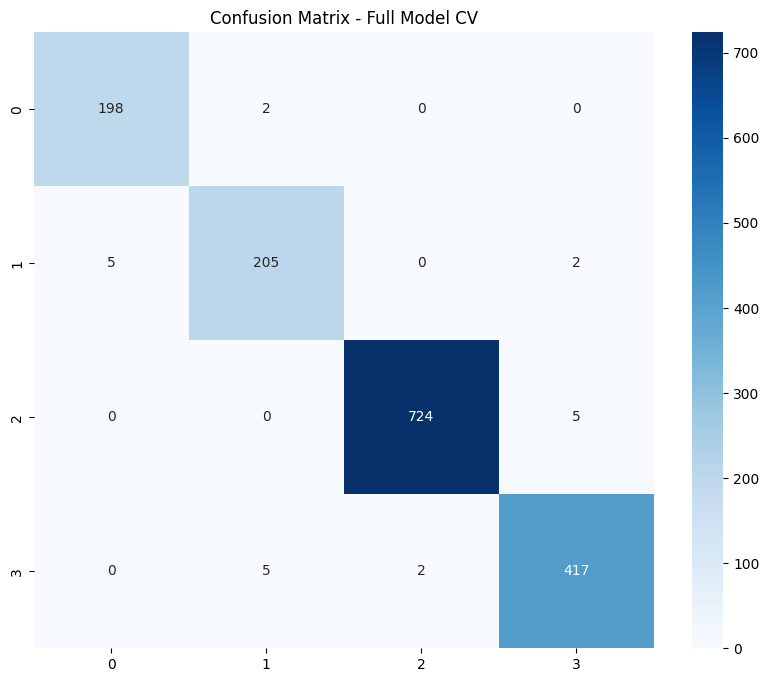

In [19]:
log_reg_study(X_HW_train, Y_HW_train)

## C BMI

[I 2025-12-26 00:35:38,703] A new study created in memory with name: no-name-323c1482-49d3-4701-ae99-da59fcd26ad0
Best trial: 0. Best value: 0.843866:   2%|▏         | 2/100 [00:00<00:05, 19.40it/s]

[I 2025-12-26 00:35:38,798] Trial 0 finished with value: 0.8438659899556564 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 1446, 'class_weight': 'balanced', 'multi_class': 'ovr'}. Best is trial 0 with value: 0.8438659899556564.
[I 2025-12-26 00:35:38,804] Trial 1 finished with value: -inf and parameters: {'C': 0.012601639723276799, 'penalty': 'l1', 'solver': 'newton-cg', 'max_iter': 966, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 0 with value: 0.8438659899556564.


Best trial: 2. Best value: 0.975666:   5%|▌         | 5/100 [00:00<00:24,  3.81it/s]

[I 2025-12-26 00:35:39,620] Trial 2 finished with value: 0.9756663280345149 and parameters: {'C': 4.418441521199722, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'max_iter': 936, 'class_weight': 'balanced', 'multi_class': 'multinomial', 'l1_ratio': 0.662522284353982}. Best is trial 2 with value: 0.9756663280345149.
[I 2025-12-26 00:35:39,626] Trial 3 finished with value: -inf and parameters: {'C': 0.07417652034871831, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 1852, 'class_weight': 'balanced', 'multi_class': 'auto'}. Best is trial 2 with value: 0.9756663280345149.
[I 2025-12-26 00:35:39,678] Trial 4 finished with value: 0.7620614470343544 and parameters: {'C': 0.042471166626171425, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1568, 'class_weight': None, 'multi_class': 'ovr'}. Best is trial 2 with value: 0.9756663280345149.
[I 2025-12-26 00:35:39,682] Trial 5 finished with value: -inf and parameters: {'C': 42.425022382673205, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 71

Best trial: 2. Best value: 0.975666:   7%|▋         | 7/100 [00:01<00:14,  6.22it/s]

...

[I 2025-12-26 00:36:53,020] Trial 92 finished with value: 0.9840099956106536 and parameters: {'C': 752.2658848007085, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 903, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:36:53,156] Trial 93 finished with value: 0.9852982722661805 and parameters: {'C': 463.7784071460902, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 843, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.


Best trial: 90. Best value: 0.986619:  97%|█████████▋| 97/100 [01:14<00:00,  8.79it/s]

[I 2025-12-26 00:36:53,232] Trial 94 finished with value: 0.9571080855863834 and parameters: {'C': 2.047108600509634, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1031, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:36:53,253] Trial 95 finished with value: -inf and parameters: {'C': 0.299798978180851, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 834, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:36:53,368] Trial 96 finished with value: 0.9853528307002912 and parameters: {'C': 163.99511658115557, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 977, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.


Best trial: 90. Best value: 0.986619: 100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


[I 2025-12-26 00:36:53,490] Trial 97 finished with value: 0.9859785284197489 and parameters: {'C': 298.09732370708207, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 998, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:36:53,511] Trial 98 finished with value: -inf and parameters: {'C': 789.1081368136901, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 1206, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:36:53,591] Trial 99 finished with value: 0.9153066420592684 and parameters: {'C': 317.62556814545803, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 725, 'class_weight': 'balanced', 'multi_class': 'ovr'}. Best is trial 90 with value: 0.9866194187626907.

Лучшие параметры:
  C: 316.23695769798627
  penalty: l2
  solver: lbfgs
  max_iter: 925
  class_weight: balanced
  multi_class: multinomial
Classification Report - Full Model CV:
        

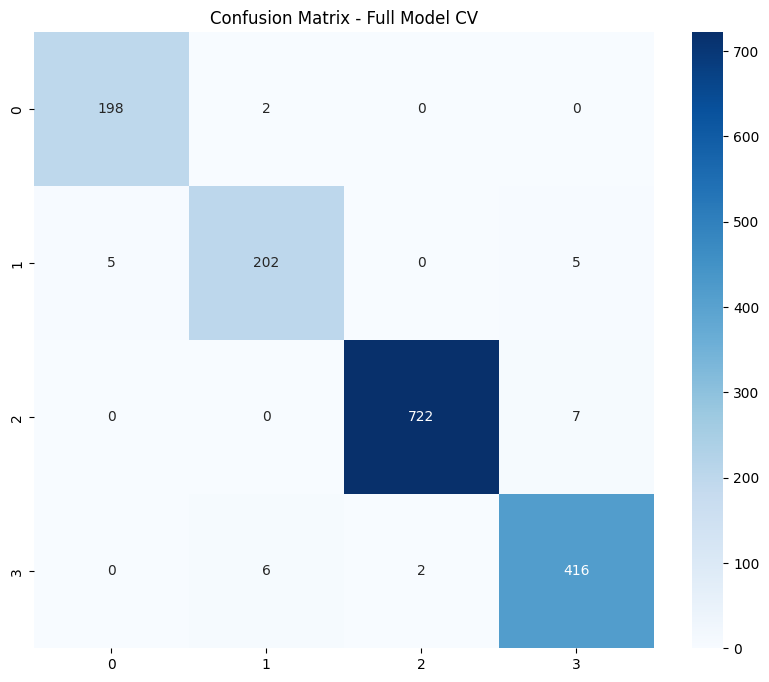

In [20]:
log_reg_study(X_BMI_train, Y_BMI_train)

## Без BMI и без Роста и Веса

[I 2025-12-26 00:37:35,433] A new study created in memory with name: no-name-22f056b4-2778-453f-ac70-f388d654434c
Best trial: 0. Best value: 0.843866:   1%|          | 1/100 [00:00<00:08, 11.09it/s]

[I 2025-12-26 00:37:35,518] Trial 0 finished with value: 0.8438659899556564 and parameters: {'C': 0.1767016940294795, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 1446, 'class_weight': 'balanced', 'multi_class': 'ovr'}. Best is trial 0 with value: 0.8438659899556564.
[I 2025-12-26 00:37:35,522] Trial 1 finished with value: -inf and parameters: {'C': 0.012601639723276799, 'penalty': 'l1', 'solver': 'newton-cg', 'max_iter': 966, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 0 with value: 0.8438659899556564.


Best trial: 2. Best value: 0.975666:   5%|▌         | 5/100 [00:00<00:29,  3.27it/s]

[I 2025-12-26 00:37:36,350] Trial 2 finished with value: 0.9756663280345149 and parameters: {'C': 4.418441521199722, 'penalty': 'elasticnet', 'solver': 'lbfgs', 'max_iter': 936, 'class_weight': 'balanced', 'multi_class': 'multinomial', 'l1_ratio': 0.662522284353982}. Best is trial 2 with value: 0.9756663280345149.
[I 2025-12-26 00:37:36,356] Trial 3 finished with value: -inf and parameters: {'C': 0.07417652034871831, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 1852, 'class_weight': 'balanced', 'multi_class': 'auto'}. Best is trial 2 with value: 0.9756663280345149.
[I 2025-12-26 00:37:36,410] Trial 4 finished with value: 0.7620614470343544 and parameters: {'C': 0.042471166626171425, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 1568, 'class_weight': None, 'multi_class': 'ovr'}. Best is trial 2 with value: 0.9756663280345149.
[I 2025-12-26 00:37:36,414] Trial 5 finished with value: -inf and parameters: {'C': 42.425022382673205, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 71

Best trial: 2. Best value: 0.975666:   7%|▋         | 7/100 [00:01<00:13,  6.87it/s]

...

[I 2025-12-26 00:38:51,975] Trial 92 finished with value: 0.9840099956106536 and parameters: {'C': 752.2658848007085, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 903, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:38:52,083] Trial 93 finished with value: 0.9852982722661805 and parameters: {'C': 463.7784071460902, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 843, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:38:52,159] Trial 94 finished with value: 0.9571080855863834 and parameters: {'C': 2.047108600509634, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1031, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.


Best trial: 90. Best value: 0.986619:  97%|█████████▋| 97/100 [01:16<00:00,  9.56it/s]

[I 2025-12-26 00:38:52,177] Trial 95 finished with value: -inf and parameters: {'C': 0.299798978180851, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 834, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:38:52,275] Trial 96 finished with value: 0.9853528307002912 and parameters: {'C': 163.99511658115557, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 977, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.


Best trial: 90. Best value: 0.986619: 100%|██████████| 100/100 [01:17<00:00,  1.30it/s]


[I 2025-12-26 00:38:52,384] Trial 97 finished with value: 0.9859785284197489 and parameters: {'C': 298.09732370708207, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 998, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:38:52,403] Trial 98 finished with value: -inf and parameters: {'C': 789.1081368136901, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 1206, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 90 with value: 0.9866194187626907.
[I 2025-12-26 00:38:52,482] Trial 99 finished with value: 0.9153066420592684 and parameters: {'C': 317.62556814545803, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 725, 'class_weight': 'balanced', 'multi_class': 'ovr'}. Best is trial 90 with value: 0.9866194187626907.

Лучшие параметры:
  C: 316.23695769798627
  penalty: l2
  solver: lbfgs
  max_iter: 925
  class_weight: balanced
  multi_class: multinomial
Classification Report - Full Model CV:
        

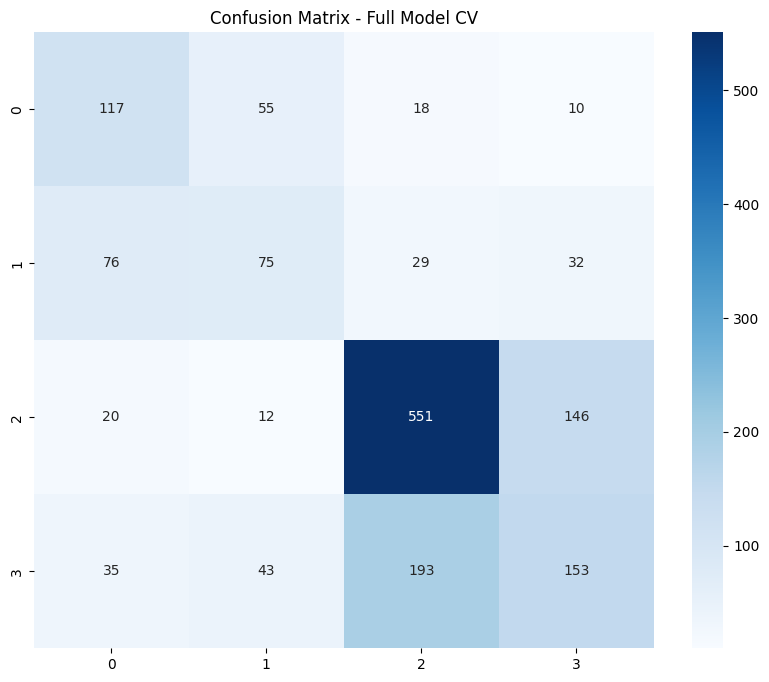

In [21]:
log_reg_study(X_NO_ANTHRO_train, Y_NO_ANTHRO_train)

### Видим, что без роста и веса мы теряем точность во много раз. Попробуем использовать полиномы.

In [ ]:
def objective(trial):
    
    params = {
        'poly__degree': trial.suggest_int('degree', 1, 3, step=1),
        'poly__interaction_only': trial.suggest_categorical('interaction_only', [True, False]),
        'poly__include_bias': trial.suggest_categorical('include_bias', [True, False]),
        'clf__C': trial.suggest_float('C', 0.001, 1000, log=True),
        'clf__penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']),
        'clf__solver': trial.suggest_categorical('solver', ['lbfgs', 'saga', 'liblinear']),
        'clf__max_iter': trial.suggest_int('max_iter', 100, 1000),
        'clf__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'clf__multi_class': trial.suggest_categorical('multi_class', ['ovr', 'multinomial', 'auto'])
    }

    if params['clf__penalty'] == 'elasticnet':
        params['clf__l1_ratio'] = trial.suggest_float('l1_ratio', 0, 1)
        params['clf__solver'] = 'saga'
    
    solver = params['clf__solver']
    penalty = params['clf__penalty']
    multi_class = params['clf__multi_class']
    
    if penalty == 'elasticnet' and solver != 'saga':
        return float('-inf')
    
    if solver == 'liblinear' and multi_class == 'multinomial':
        return float('-inf')
    
    if penalty == 'l1' and solver not in ['liblinear', 'saga']:
        return float('-inf')
    
    if penalty == 'none' and solver not in ['lbfgs', 'newton-cg', 'sag', 'saga']:
        return float('-inf')
    
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(
            degree=params['poly__degree'],
            interaction_only=params['poly__interaction_only'],
            include_bias=params['poly__include_bias']
        )),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            random_state=42,
            C=params['clf__C'],
            penalty=params['clf__penalty'],
            solver=params['clf__solver'],
            max_iter=params['clf__max_iter'],
            class_weight=params['clf__class_weight'],
            multi_class=params['clf__multi_class'],
            l1_ratio=params.get('clf__l1_ratio', None)
        ))
    ])
    
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    try:
        scores = cross_val_score(
            pipeline, 
            X_NO_ANTHRO_train, 
            Y_NO_ANTHRO_train, 
            cv=stratified_kfold, 
            scoring='f1_weighted',
            n_jobs=-1
        )
        return scores.mean()
    except Exception as e:
        # Если возникает ошибка, возвращаем плохой результат
        return float('-inf')

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
    study_name='polynomial_logistic_regression'
)

study.optimize(objective, n_trials=150, show_progress_bar=True)


print("\nЛучшие параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_params = study.best_params.copy()

# Подготавливаем параметры для PolynomialFeatures
poly_params = {
    'degree': best_params.get('degree', 2),
    'interaction_only': best_params.get('interaction_only', False),
    'include_bias': best_params.get('include_bias', False)
}

# Подготавливаем параметры для LogisticRegression
logreg_params = {
    'random_state': 42,
    'C': best_params.get('C'),
    'penalty': best_params.get('penalty'),
    'solver': best_params.get('solver'),
    'max_iter': best_params.get('max_iter', 1000),
    'class_weight': best_params.get('class_weight'),
    'multi_class': best_params.get('multi_class')
}

if best_params.get('penalty') == 'elasticnet' and 'l1_ratio' in best_params:
    logreg_params['l1_ratio'] = best_params['l1_ratio']

logreg_params = {k: v for k, v in logreg_params.items() if v is not None}

# Создаем финальный пайплайн с лучшими параметрами
best_pipeline = Pipeline([
    ('poly', PolynomialFeatures(**poly_params)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(**logreg_params))
])

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv_full = cross_val_predict(estimator=best_pipeline, 
                                X=X_NO_ANTHRO_train,
                                y=Y_NO_ANTHRO_train,
                                cv=stratified_kfold, 
                                n_jobs=-1)

print("Classification Report - Full Model CV:")
print(classification_report(Y_NO_ANTHRO_train, y_pred_cv_full, target_names=Y_NO_ANTHRO_train.unique()))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(Y_NO_ANTHRO_train, y_pred_cv_full), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Full Model CV')
plt.show()

[I 2025-12-26 01:05:51,399] A new study created in memory with name: polynomial_logistic_regression
Best trial: 0. Best value: 0.430829:   1%|          | 1/150 [00:05<14:19,  5.77s/it]

[I 2025-12-26 01:05:57,167] Trial 0 finished with value: 0.43082916202401156 and parameters: {'degree': 2, 'interaction_only': True, 'include_bias': True, 'C': 0.008629132190071854, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 850, 'class_weight': None, 'multi_class': 'auto'}. Best is trial 0 with value: 0.43082916202401156.


Best trial: 1. Best value: 0.659489:   1%|▏         | 2/150 [00:12<15:17,  6.20s/it]

[I 2025-12-26 01:06:03,669] Trial 1 finished with value: 0.6594885709964997 and parameters: {'degree': 2, 'interaction_only': False, 'include_bias': False, 'C': 0.1578232781079558, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 647, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 1 with value: 0.6594885709964997.
[I 2025-12-26 01:06:03,677] Trial 2 finished with value: -inf and parameters: {'degree': 1, 'interaction_only': False, 'include_bias': True, 'C': 0.9355380606452179, 'penalty': 'l1', 'solver': 'lbfgs', 'max_iter': 592, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 1 with value: 0.6594885709964997.


Best trial: 1. Best value: 0.659489:   3%|▎         | 4/150 [00:16<08:52,  3.65s/it]

...

[I 2025-12-26 01:06:54,023] Trial 13 finished with value: 0.7148116703194687 and parameters: {'degree': 3, 'interaction_only': True, 'include_bias': False, 'C': 32.107275357780594, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 239, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 13 with value: 0.7148116703194687.


Best trial: 13. Best value: 0.714812:  10%|█         | 15/150 [01:03<08:22,  3.72s/it]

[I 2025-12-26 01:06:54,770] Trial 14 finished with value: 0.683482609671221 and parameters: {'degree': 2, 'interaction_only': True, 'include_bias': False, 'C': 26.828108418639747, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 163, 'class_weight': None, 'multi_class': 'multinomial'}. Best is trial 13 with value: 0.7148116703194687.


Best trial: 13. Best value: 0.714812:  11%|█         | 16/150 [01:07<08:27,  3.79s/it]

[I 2025-12-26 01:06:58,719] Trial 15 finished with value: 0.7134160440842436 and parameters: {'degree': 3, 'interaction_only': True, 'include_bias': False, 'C': 59.406265927300915, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 252, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 13 with value: 0.7148116703194687.
[I 2025-12-26 01:06:58,738] Trial 16 finished with value: -inf and parameters: {'degree': 2, 'interaction_only': True, 'include_bias': False, 'C': 33.41819459770575, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 100, 'class_weight': 'balanced', 'multi_class': 'multinomial'}. Best is trial 13 with value: 0.7148116703194687.


# **2.3. SVM**

In [ ]:
svm_pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', random_state=42, probability=True)
    )

## Без BMI

In [ ]:
make_model(svm_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["svm"], result_hw)

## С BMI

In [ ]:
make_model(svm_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["svm"], result_bmi)

## Без BMI и без Роста и Веса

In [ ]:
make_model(svm_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["svm"], result_no_anthro)

# **2.4. Дерево решений**

In [ ]:
dt_pipeline = make_pipeline(
    DecisionTreeClassifier(random_state=42)
)


## Без BMI

In [ ]:
make_model(dt_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["tree"], result_hw)

## C BMI

In [ ]:
make_model(dt_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["tree"], result_bmi)

## Без BMI и без Роста и Веса

In [ ]:
make_model(dt_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["tree"], result_no_anthro)

# **2.5. Бэггинг (Random Forest)**

In [ ]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)

## Без BMI

In [ ]:
make_model(rf_pipeline, X_HW_train, Y_HW_train, MODEL_NAMES["rf"], result_hw)

## С BMI

In [ ]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi)

## Без BMI и без Роста и Веса

In [ ]:
make_model(rf_pipeline, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["rf"], result_no_anthro)

# **2.6. Стекинг**

In [ ]:
estimators = [
    ('logreg', logreg_pipeline),
    ('svm', svm_pipeline),
    ('rf', rf_pipeline),
    ('dt', dt_pipeline)
]

final_estimator = LogisticRegression()

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1
)

stacking

## Без BMI

In [ ]:
make_model(stacking, X_HW_train, Y_HW_train, MODEL_NAMES["stacking"], result_hw)

## C BMI

In [ ]:
make_model(stacking, X_BMI_train, Y_BMI_train, MODEL_NAMES["stacking"], result_bmi)

## Без BMI и без Роста и Веса

In [ ]:
make_model(stacking, X_NO_ANTHRO_train, Y_NO_ANTHRO_train, MODEL_NAMES["stacking"], result_no_anthro)

# **2.7. Бустинг (CatBoost)**

In [ ]:
cbreg = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    loss_function='MultiClass',
    random_seed=42,
    verbose=0
)

In [ ]:
make_catboost_model(cbreg, X_HW_cat_train, Y_HW_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_hw)

In [ ]:
make_catboost_model(cbreg, X_BMI_cat_train, Y_BMI_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_bmi)

## Без BMI и без Роста и Веса

In [ ]:
make_catboost_model(cbreg, X_NO_ANTHRO_cat_train, Y_NO_ANTHRO_cat_train, cat_features , MODEL_NAMES["cat_boost"], result_no_anthro)

# **3.1. Таблицы сравнений**

Итак, выведем полученные значения из наших моделей:

In [ ]:
print("\n### 1.  Результаты без показателя BMI (Рост/Вес включены)")
display_formatted_table(result_hw)
print("\n### 2.  Результаты c показателем BMI (Рост/Вес не включены)")
display_formatted_table(result_bmi)
print("\n### 3.  Результаты без антропометрических данных (Без BMI, Роста и Веса)")
display_formatted_table(result_no_anthro)

## **Какие же данные лучше всего использовать в дальнейшем?**
Сравнивая таблицы сравнений между собой можно сделать вывод, что **Данные С BMI** улучшают модель, чем без нее, а без признаков о весе и росте вычисления становятся в разы хуже



In [ ]:
print("Результаты c показателем BMI (Рост/Вес включены)")
display_formatted_table(result_bmi)

## **Какую модель мы выберем для дальнейшего развития?**
Даже среди трех разных данных, то лучший результат по точности показал **Стекинг**, находясь всегда на первом месте.

Однако, так как мы выбрали одни данные на которых далее будем развивать нашу модель, то кандитатом на выбор модели является **Случайный лес** за счет его скорости и не сильного отстования по точности.

# **3.2 Сравнения двух лучших моделей**

Для выбранных моделей выведем кросс-валидацию, обучение на тестовой выборки

In [ ]:
make_model(stacking, X_BMI_train, Y_BMI_train, MODEL_NAMES["stacking"], result_bmi)

display_final_model_evaluation(stacking, X_BMI_train, Y_BMI_train, X_BMI_test, Y_BMI_test, MODEL_NAMES["stacking"])

In [ ]:
make_model(rf_pipeline, X_BMI_train, Y_BMI_train, MODEL_NAMES["rf"], result_bmi)

display_final_model_evaluation(rf_pipeline, X_BMI_train, Y_BMI_train, X_BMI_test, Y_BMI_test, MODEL_NAMES["rf"])

Так как значения у двух моделей совпадают, то можно предположить, что переобучение отсуствует

# **3.3 Выводы**

В данном ноутбуке были проведены обучение 6-и базовых моделей на кросс-валидации и их сравнения для получения модели, которую будем использовать в дальнейшим для ее улучшения. Кандитатами на данную роль являются **Случайный лес** и **Стекинг**.

Точно нельзя сказать, какая модель лучше: **Случайный лес** запускается быстрее, однако **Стекинг** выполняется более точным. Поэтому дальнейшую модель стоит выбирать в зависимости от ресурсов и целей, которых хотим добиться.